# 02 — Supervised Baseline (ISIC 2018)

Minimal baseline notebook: train once, reuse saved weights if they already exist, then print report-ready metrics and figures. Training logic lives in `src/trainers/supervised.py`.

In [1]:
import os
import sys
from pathlib import Path

# Keep project root on sys.path so `src` imports work inside the notebook
root = Path.cwd()
if root.name == "notebooks":
    root = root.parent
os.chdir(root)
sys.path.insert(0, str(root))

from src.datasets import build_loaders
from src.models import build_backbone
from src.reporting import evaluate_and_report, evaluate_on_csv, get_latest_run, plot_training_history, collect_auc_vs_fraction
from src.trainers.supervised import run_experiment
from src.utils import get_device, load_config
from src.metrics import plot_auc_vs_labels
from data.scripts.make_label_subsets import main as generate_subsets

## 1. Load config

In [2]:
config = load_config("configs/baseline.yaml")
config

{'experiment': {'name': 'baseline_resnet18_full',
  'seed': 42,
  'device': 'auto'},
 'data': {'task': 'supervised',
  'train_csv': 'data/processed/isic2018/train.csv',
  'val_csv': 'data/processed/isic2018/val.csv',
  'test_csv': 'data/processed/isic2018/test.csv',
  'img_size': 224,
  'batch_size': 64,
  'num_workers': 4,
  'use_weighted_sampler': True,
  'label_col': 'target'},
 'model': {'arch': 'resnet18', 'pretrained': True, 'num_classes': 1},
 'training': {'epochs': 50,
  'optimizer': 'adamw',
  'lr_backbone': 0.0001,
  'lr_head': 0.001,
  'weight_decay': 0.0001,
  'scheduler': 'cosine',
  'freeze_backbone_epochs': 5},
 'loss': {'type': 'focal', 'gamma': 2.0, 'alpha': 0.75},
 'early_stopping': {'patience': 10, 'monitor': 'val_auc'},
 'logging': {'save_dir': 'results/runs', 'log_every': 10}}

## 2. Run baseline

Train once if needed. If a run already exists, the notebook reuses the saved checkpoint instead of retraining.

In [3]:
RUN_TRAINING = False   # set to True only to retrain

exp_name = config["experiment"]["name"]

if RUN_TRAINING:
    result = run_experiment(config)
    run_dir = Path(result["run_dir"])
else:
    run_dir = get_latest_run(exp_name)
    if run_dir is None:
        raise FileNotFoundError(
            f"No runs found for '{exp_name}' under results/runs. "
            "Set RUN_TRAINING = True to create a new run."
        )

print("Run dir:", run_dir)

Run dir: results/runs/baseline_resnet18_full/20260530_140056


## 3. Evaluate best checkpoint on test set

Print report-ready metrics and save confusion matrix, ROC curve, and training-history plot.

/opt/homebrew/Caskroom/miniconda/base/envs/isic-dl/lib/python3.11/site-packages/torch/utils/data/sampler.py:227: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403251597/work/torch/csrc/utils/tensor_numpy.cpp:212.)
  weights_tensor = torch.as_tensor(weights, dtype=torch.double)



=== Test Set Evaluation ===
  AUC-ROC:            0.9181
  Balanced Accuracy:  0.8318
  Macro F1:           0.6670
  Precision (Malig):  0.3227
  Recall (Malig):     0.9018
  Confusion matrix:
[[678 212]
 [ 11 101]]

Artifacts saved to: results/runs/baseline_resnet18_full/20260530_140056


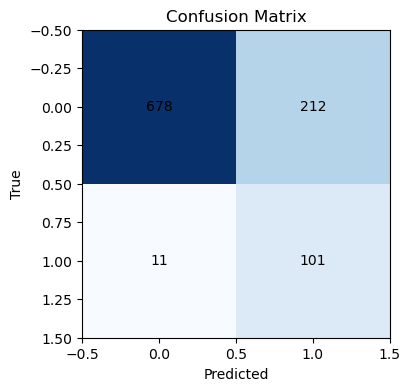

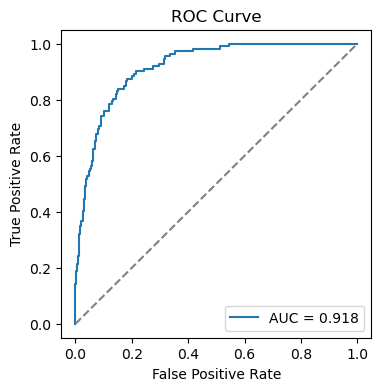

In [4]:
# Build test loader and model (model will be loaded inside evaluate_and_report)
loaders = build_loaders(config)
device = get_device(config["experiment"].get("device"))
model = build_backbone(
    arch=config["model"]["arch"],
    pretrained=config["model"].get("pretrained", True),
    num_classes=config["model"].get("num_classes", 1),
)

# Run evaluation: computes metrics, saves test_metrics.json, generates figures
metrics = evaluate_and_report(run_dir, model, loaders["test"], device)

In [5]:
plot_training_history(run_dir, save_path=str(run_dir / "figures" / "training_history.png"))

In [6]:
# Cell 11: Generate label subsets if they don't exist

subset_dir = Path("data/processed/isic2018/subsets")
subset_files_exist = subset_dir.exists() and any(subset_dir.glob("train_*.csv"))

if not subset_files_exist:
    print("Generating label subsets...")
    generate_subsets()   # runs the script's main logic
    print("Done.")
else:
    print("Label subsets already exist.")

Label subsets already exist.


In [7]:
# Cell 12 – Train label-budget models and generate test metrics (ISIC 2018)
from data.scripts.make_label_subsets import FRACTIONS
import copy
import json

exp_name_prefix = "baseline_resnet18_{:.2f}"
base_config = copy.deepcopy(config)

for frac in FRACTIONS:
    exp_name = exp_name_prefix.format(frac)
    run_dir = get_latest_run(exp_name)

    has_checkpoint = False
    has_test_metrics = False
    if run_dir is not None:
        ckpt_path = run_dir / "checkpoints/best.pt"
        metrics_path = run_dir / "test_metrics.json"
        has_checkpoint = ckpt_path.exists()
        has_test_metrics = metrics_path.exists()

    if has_checkpoint and has_test_metrics:
        print(f"Skipping {exp_name} (already complete)")
        continue

    # If checkpoint exists but no test metrics, just evaluate
    if has_checkpoint and not has_test_metrics:
        print(f"Found checkpoint for {exp_name}, evaluating on test set...")
        cfg = copy.deepcopy(base_config)
        pct = int(round(frac * 100))
        cfg["data"]["train_csv"] = f"data/processed/isic2018/subsets/train_{pct:02d}pct.csv"
        loaders = build_loaders(cfg)
        device = get_device(cfg["experiment"].get("device", "auto"))
        model = build_backbone(
            arch=cfg["model"]["arch"],
            pretrained=cfg["model"].get("pretrained", True),
            num_classes=cfg["model"].get("num_classes", 1),
        )
        evaluate_and_report(run_dir, model, loaders["test"], device)
        print(f"Evaluation done for {exp_name}")
        continue

    # Otherwise, train from scratch
    print(f"\nTraining {exp_name}...")
    cfg = copy.deepcopy(base_config)
    cfg["experiment"]["name"] = exp_name
    pct = int(round(frac * 100))
    cfg["data"]["train_csv"] = f"data/processed/isic2018/subsets/train_{pct:02d}pct.csv"

    result = run_experiment(cfg)
    run_dir = Path(result["run_dir"])

    loaders = build_loaders(cfg)
    device = get_device(cfg["experiment"].get("device", "auto"))
    model = build_backbone(
        arch=cfg["model"]["arch"],
        pretrained=cfg["model"].get("pretrained", True),
        num_classes=cfg["model"].get("num_classes", 1),
    )
    evaluate_and_report(run_dir, model, loaders["test"], device)
    print(f"Finished training and evaluation for {exp_name}")

Skipping baseline_resnet18_0.01 (already complete)
Skipping baseline_resnet18_0.05 (already complete)
Skipping baseline_resnet18_0.10 (already complete)
Skipping baseline_resnet18_0.25 (already complete)
Skipping baseline_resnet18_0.50 (already complete)


[cached] baseline_resnet18_0.01 → ISIC2020 AUC = 0.6619
[cached] baseline_resnet18_0.05 → ISIC2020 AUC = 0.7118
[cached] baseline_resnet18_0.10 → ISIC2020 AUC = 0.6853
[cached] baseline_resnet18_0.25 → ISIC2020 AUC = 0.6294
[cached] baseline_resnet18_0.50 → ISIC2020 AUC = 0.6353
Full (100%) → 2018=0.9181  2020=0.6975

Domain gap at each label fraction:
     1%  →  2018=0.8138  2020=0.6619  gap=+0.1519
     5%  →  2018=0.8629  2020=0.7118  gap=+0.1511
    10%  →  2018=0.8631  2020=0.6853  gap=+0.1778
    25%  →  2018=0.8679  2020=0.6294  gap=+0.2384
    50%  →  2018=0.9065  2020=0.6353  gap=+0.2713
   100%  →  2018=0.9181  2020=0.6975  gap=+0.2206


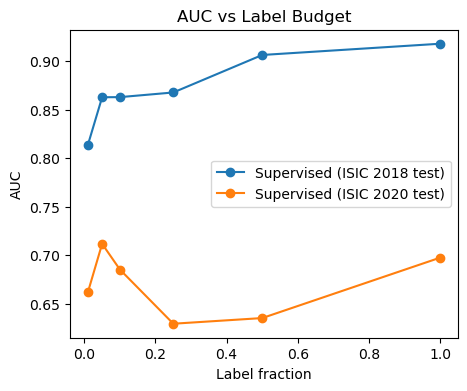

In [8]:
# Cell 13 – Evaluate on ISIC 2020 (domain gap) + plot AUC vs label budget
import json

device = get_device(config["experiment"].get("device", "auto"))

# ── 1. Fractions 1%–50% ───────────────────────────────────────────────────
aucs_2018 = collect_auc_vs_fraction(exp_name_prefix, FRACTIONS)
aucs_2020 = {}

for frac in FRACTIONS:
    exp_name = exp_name_prefix.format(frac)
    run_dir = get_latest_run(exp_name)
    if run_dir is None:
        print(f"Warning: no run found for {exp_name}")
        aucs_2020[frac] = None
        continue
    metrics = evaluate_on_csv(
        run_dir,
        config,
        test_csv="data/processed/isic2020/test.csv",
        batch_size=64,
        device=device,
        metrics_name="test_metrics_isic2020.json",
    )
    auc = None if metrics is None else metrics.get("auc_roc")
    aucs_2020[frac] = auc
    cached = (run_dir / "test_metrics_isic2020.json").exists()
    tag = "[cached]" if cached else ""
    print(f"{tag} {exp_name} → ISIC2020 AUC = {auc:.4f}" if auc else f"Missing: {exp_name}")

# ── 2. Full dataset point (E1 baseline_resnet18_full) ─────────────────────
full_run_dir = get_latest_run("baseline_resnet18_full")
if full_run_dir is not None:
    # ISIC 2018 — load from existing test_metrics.json
    tm_path = full_run_dir / "test_metrics.json"
    auc_full_2018 = json.load(open(tm_path)).get("auc_roc") if tm_path.exists() else None

    # ISIC 2020 — evaluate (or load cache)
    metrics_full = evaluate_on_csv(
        full_run_dir,
        config,
        test_csv="data/processed/isic2020/test.csv",
        batch_size=64,
        device=device,
        metrics_name="test_metrics_isic2020.json",
    )
    auc_full_2020 = None if metrics_full is None else metrics_full.get("auc_roc")

    if auc_full_2018:
        aucs_2018[1.0] = auc_full_2018
    if auc_full_2020:
        aucs_2020[1.0] = auc_full_2020
    print(f"Full (100%) → 2018={auc_full_2018:.4f}  2020={auc_full_2020:.4f}" if auc_full_2018 and auc_full_2020 else "Full run incomplete")
else:
    print("Warning: baseline_resnet18_full run not found, skipping 100% point")

# ── 3. Plot ────────────────────────────────────────────────────────────────
from pathlib import Path as _Path
_Path("results/figures").mkdir(parents=True, exist_ok=True)

results = {
    "Supervised (ISIC 2018 test)": {f: v for f, v in aucs_2018.items() if v is not None},
    "Supervised (ISIC 2020 test)": {f: v for f, v in aucs_2020.items() if v is not None},
}

fig = plot_auc_vs_labels(
    results,
    save_path="results/figures/auc_vs_labels_baseline.png",
)

# ── 4. Domain gap summary ─────────────────────────────────────────────────
all_fracs = sorted(set(aucs_2018) | set(aucs_2020))
print("\nDomain gap at each label fraction:")
for frac in all_fracs:
    a18 = aucs_2018.get(frac)
    a20 = aucs_2020.get(frac)
    label = f"{int(frac*100):4d}%"
    if a18 is not None and a20 is not None:
        print(f"  {label}  →  2018={a18:.4f}  2020={a20:.4f}  gap={a18-a20:+.4f}")
    else:
        print(f"  {label}  →  data missing")